# **Student Depression Analysis**


## **Introduction**

This capstone project is conducted as part of the Google Data Analytics Certification. The objective is to analyze a real-world dataset "the Student Depression Dataset" to explore key factors that may contribute to depression among students. 

The analysis will follow the six-phase Google Data Analysis process: Ask, Prepare, Process, Analyze, Share, and Act.

The project will use the R programming language in a Jupyter Notebook environment for all steps including data cleaning, visualization, and reporting.


## **The Ask Phrase**

**Key Tasks:**
1. **Identify the Business Task:** 

    The business task is to analyze student-level data to identify the key factors associated with depression, with the goal of understanding the underlying contributors to mental health issues and helping institutions design data-driven early intervention strategies that support student mental health.

2. **Determine key stakeholders:**
    - Business Intelligence Consultant (my employer)
    - Client Institutions (e.g., schools, colleges, or mental health organizations)
    - Academic Advisors & Counselors
    - Students & Families (indirect stakeholders benefiting from the insights)

3. **Choose a Dataset:**
    - **Dataset Name:** [Student Depression Dataset](https://www.kaggle.com/datasets/adilshamim8/student-depression-dataset)
    - **Source:** Kaggle
    - **Format:** CSV
    - **License:** Apache 2.0
    - **Content:** Demographic, academic, lifestyle, and psychological factors related to depression in students.

## **The Prepare Phase**

### **About the Dataset**
This dataset compiles a wide range of information aimed at understanding, analyzing, and predicting depression levels among students. It is designed for research in psychology, data science, and education, providing insights into factors that contribute to student mental health challenges and aiding in the design of early intervention strategies.

    

### **ROCCC Assessment: Does the Data Meet Key Quality Standards?**

| **Criterion**     | **Definition**                                                                                       | **Evaluation**                                                                                                                                                                                                                              |
|------------------|------------------------------------------------------------------------------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Reliable**      | Data comes from a trustworthy source and collection process; low risk of errors or bias.            | **Moderate to High** – Though hosted on Kaggle, the data was originally gathered through anonymized, self-reported surveys using standardized instruments across institutions, and cleaned prior to release, improving its reliability.     |
| **Original**      | Data is primary (not aggregated or re-reported), collected firsthand for the intended purpose.      | **Yes** – The dataset consists of firsthand responses collected directly from students to explore depression-related patterns, making it suitable for original analysis.                                                                    |
| **Comprehensive** | Contains all variables needed to answer your business questions and explore the problem space.      | **Yes** – Covers demographics, academics, lifestyle, and psychological indicators, providing a well-rounded foundation for mental health analysis and intervention strategy design.                                                         |
| **Current**       | Data is up-to-date and reflects the time period relevant to your analysis.                          | **Unclear / Possibly Low** – The exact time of data collection is not specified, making it difficult to determine its temporal relevance to current student mental health trends.                                                           |
| **Cited**         | Source and authorship are clearly documented and can be referenced.                                 | **Yes** – Dataset is publicly available on Kaggle with proper licensing (Apache 2.0) and documentation. Ethical preparation steps such as anonymization, normalization, and feature selection are also clearly noted by the dataset authors. |



### **Load the Required Libraries** 

In [20]:
# Load the required packages
# For reading the dataset, I am using the reading function of the autofileIO
# package which is created by me. The autofileIO package contains a reading
# (auto_read()) and a writing function (auto_write()) that automatically
# detects the file type or a database connection and uses the appropriate
# reading and writing function.
# Check it out here: https://github.com/ankito090/autofileIO.git
library(autofileIO)
library(dplyr)
library(janitor)
library(tidyr)
library(skimr)
library(ggplot2)
library(stringr)
library(forcats)

### **Read the Dataset**

In [21]:
# Read the dataset
data <- autofileIO::auto_read("student_depression_dataset.csv", na = "?")

# Preview the structure of the dataset
glimpse(data)

Rows: 27,901
Columns: 18
$ id                                      <dbl> 2, 8, 26, 30, 32, 33, 52, 56, …
$ Gender                                  <chr> "Male", "Female", "Male", "Fem…
$ Age                                     <dbl> 33, 24, 31, 28, 25, 29, 30, 30…
$ City                                    <chr> "Visakhapatnam", "Bangalore", …
$ Profession                              <chr> "Student", "Student", "Student…
$ `Academic Pressure`                     <dbl> 5, 2, 3, 3, 4, 2, 3, 2, 3, 2, …
$ `Work Pressure`                         <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ CGPA                                    <dbl> 8.97, 5.90, 7.03, 5.59, 8.13, …
$ `Study Satisfaction`                    <dbl> 2, 5, 5, 2, 3, 3, 4, 4, 1, 3, …
$ `Job Satisfaction`                      <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ `Sleep Duration`                        <chr> "'5-6 hours'", "'5-6 hours'", …
$ `Dietary Habits`                        <chr> "Healthy", "Moderate", "Health…
$ Degree       

## **The Process Phase**

In [22]:
# Standardize column names by converting them to a consistent format
data <- clean_names(data)

In [23]:
# Identify if there are any duplicate rows
get_dupes(data)

No variable names specified - using all columns.


No duplicate combinations found of: id, gender, age, city, profession, academic_pressure, work_pressure, cgpa, study_satisfaction, ... and 9 other variables



id,gender,age,city,profession,academic_pressure,work_pressure,cgpa,study_satisfaction,job_satisfaction,sleep_duration,dietary_habits,degree,have_you_ever_had_suicidal_thoughts,work_study_hours,financial_stress,family_history_of_mental_illness,depression,dupe_count
<dbl>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<int>


In [24]:
# Check for missing values
colSums(is.na(data))

# Display the distribution of unique values in the financial_stress column
data |> count(financial_stress, name = "count_of_unique_values")

# Replace the 3 NA values in the financial_stress column with the mode (5),
# since 5 is the most frequently occurring value in this ordinal variable.
# Given the very low number of missing values (~0.01%), using the mode helps
# preserve the existing distribution without significantly biasing the dataset.
data <- replace_na(data, list(financial_stress = 5))

# Verify the removal of the NA values
cat(ifelse(
  !any(is.na(data)),
  "All the NA values are successfully removed!",
  "There are NA values in the data!"
))

id                              gender 
                                  0                                   0 
                                age                                city 
                                  0                                   0 
                         profession                   academic_pressure 
                                  0                                   0 
                      work_pressure                                cgpa 
                                  0                                   0 
                 study_satisfaction                    job_satisfaction 
                                  0                                   0 
                     sleep_duration                      dietary_habits 
                                  0                                   0 
                             degree have_you_ever_had_suicidal_thoughts 
                                  0                                   0 
                   work_study_hours                    financial_stress 
                                  0                                   3 
   family_history_of_mental_illness                          depression 
                                  0                                   0

financial_stress,count_of_unique_values
<dbl>,<int>
1,5121
2,5061
3,5226
4,5775
5,6715
NA,3


All the NA values are successfully removed!

In [25]:
# Change the appropriate or required categorical columns to factors
data$gender <- factor(data$gender, levels = c("Male", "Female"))
data$academic_pressure <- factor(
  data$academic_pressure,
  levels = c(0, 1, 2, 3, 4, 5),
  labels = c("None", "Very Low", "Low", "Moderate", "High", "Very High")
)
data$study_satisfaction <- factor(
  data$study_satisfaction,
  levels = c(0, 1, 2, 3, 4, 5),
  labels = c("None", "Very Low", "Low", "Moderate", "High", "Very High")
)
data$sleep_duration <- factor(
  data$sleep_duration,
  levels = c(
    "'Less than 5 hours'", "'5-6 hours'", "'7-8 hours'",
    "'More than 8 hours'", "Others"
  ),
  labels = c(
    "Less than 5 hours", "5-6 hours", "7-8 hours",
    "More than 8 hours", "Others"
  )
)
data$dietary_habits <- factor(
  data$dietary_habits,
  levels = c("Unhealthy", "Moderate", "Healthy", "Others")
)
data$financial_stress <- factor(
  data$financial_stress,
  levels = c(1, 2, 3, 4, 5),
  labels = c("Very Low", "Low", "Moderate", "High", "Very High")
)
data$have_you_ever_had_suicidal_thoughts <- factor(
  data$have_you_ever_had_suicidal_thoughts,
  levels = c("Yes", "No")
)
data$family_history_of_mental_illness <- factor(
  data$family_history_of_mental_illness,
  levels = c("Yes", "No")
)


## **The Analyze and The Share Phase**

### **1. Demographics: Do certain groups experience more depression?** 

#### **a. Gender vs Depression**

gender,total_respondents,have_depression,depression_percentage
<fct>,<int>,<dbl>,<dbl>
Male,15547,9115,58.63
Female,12354,7221,58.45


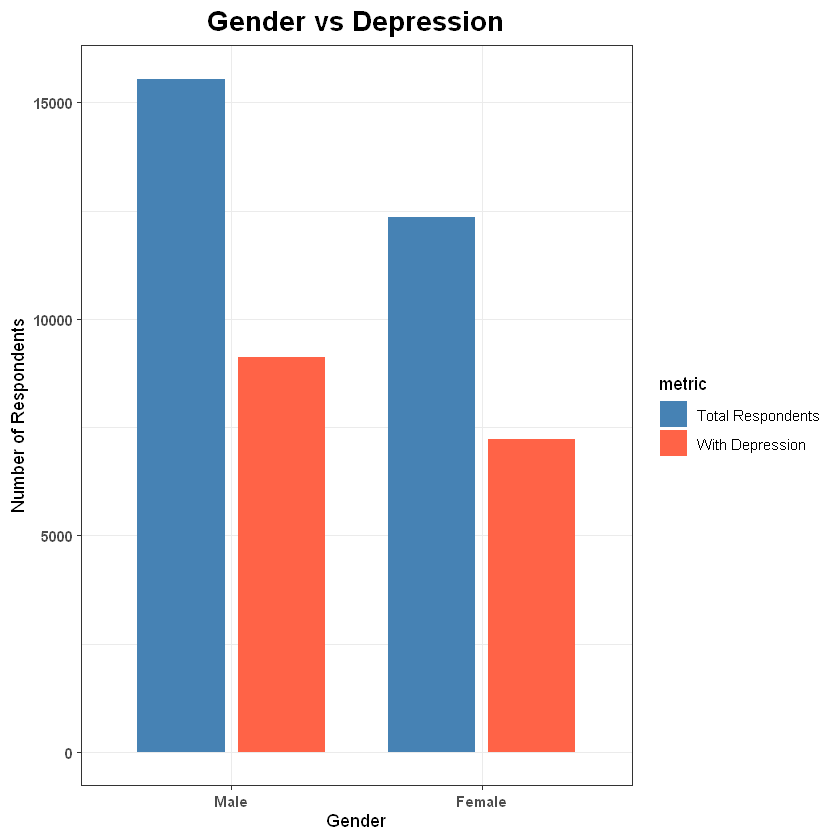

In [27]:
# Group the data by gender and find the sum of respondents having depression
# and their percentage for each gender
gender_vs_depression <- data |>
  group_by(gender) |>
  summarize(
    total_respondents = n(),
    have_depression = sum(depression),
    depression_percentage = round(have_depression / total_respondents * 100, 2)
  )

# Display the resulting tibble
gender_vs_depression

# Convert the tibble to a longer format
gender_vs_depression <- gender_vs_depression |>
  select(gender, total_respondents, have_depression) |>
  pivot_longer(
    c(total_respondents, have_depression),
    names_to = "metric",
    values_to = "count"
  ) |>
  mutate(metric = factor(
    metric, levels = c("total_respondents", "have_depression")
  ))

# Visualize the result in a vertical bar plot
ggplot(gender_vs_depression, aes(x = gender, y = count, fill = metric)) +
  geom_col(position = position_dodge(width = 0.8), width = 0.7) +
  labs(
    title = "Gender vs Depression",
    x = "Gender",
    y = "Number of Respondents"
  ) +
  scale_fill_manual(
    values = c(
      total_respondents = "steelblue",
      have_depression   = "tomato"
    ),
    labels = c(
      total_respondents = "Total Respondents",
      have_depression   = "With Depression"
    )
  ) +
  theme_bw() +
  theme(
    plot.title = element_text(face = "bold", size = 17, hjust = 0.5),
    axis.text.x = element_text(face = "bold"),
    axis.text.y = element_text(face = "bold")
  )

##### **Interpretation**

* Among the 15,547 male respondents, 9,115 (= 58.6%) reported having depression.
* Among the 12,354 female respondents, 7,221 (= 58.5%) reported having depression.

This indicates that the prevalence of depression is nearly identical across genders in this dataset, with both male and female students reporting depression at around 58.5%–58.6%. Therefore, gender may not be a strong distinguishing factor for depression levels among these respondents.

#### **b. Age vs Depression**

Summary Stats of the age column:

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  18.00   21.00   25.00   25.82   30.00   59.00 

age_group,total_respondents,with_depression,depression_percentage
<fct>,<int>,<dbl>,<dbl>
18–21,7110,5064,71.22
22–25,6847,4343,63.43
26–29,6700,3961,59.12
30+,7244,2968,40.97


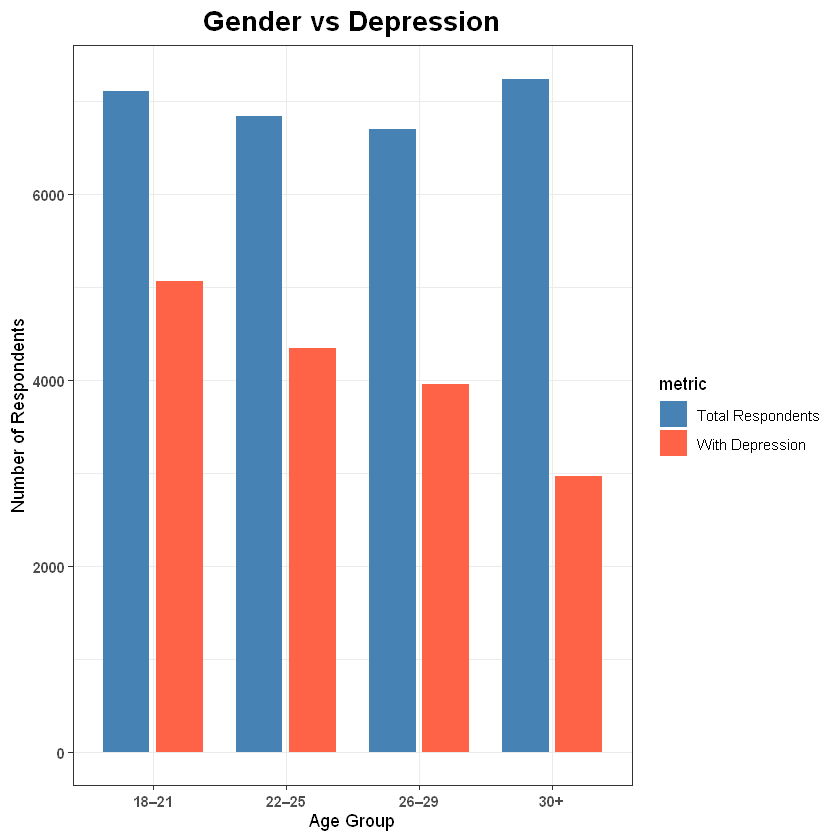

In [28]:
# Display the summary stats of the age column
cat(paste0("Summary Stats of the age column:"))
summary(data$age)

# Create a age_group column based on defined age ranges
# and compute depression stats across each group
age_vs_depression <- data |>
  mutate(
    age_group = case_when(
      age >= 18 & age <= 21 ~ "18–21",
      age >= 22 & age <= 25 ~ "22–25",
      age >= 26 & age <= 29 ~ "26–29",
      age >= 30             ~ "30+"
    ),
    age_group = factor(age_group, levels = c("18–21", "22–25", "26–29", "30+"))
  ) |>
  group_by(age_group) |>
  summarize(
    total_respondents = n(),
    with_depression = sum(depression),
    depression_percentage = round(with_depression / total_respondents * 100, 2)
  )

# Display the resulting tibble
age_vs_depression

# Convert the tibble to a longer format
age_vs_depression_long <- age_vs_depression |>
  select(age_group, total_respondents, with_depression) |>
  pivot_longer(
    c(total_respondents, with_depression),
    names_to = "metric",
    values_to = "count"
  ) |>
  mutate(metric = factor(
    metric, levels = c("total_respondents", "with_depression")
  ))

# Visualize the result in a vertical bar plot
ggplot(age_vs_depression_long, aes(x = age_group, y = count, fill = metric)) +
  geom_col(position = position_dodge(width = 0.8), width = 0.7) +
  labs(
    title = "Gender vs Depression",
    x = "Age Group",
    y = "Number of Respondents"
  ) +
  scale_fill_manual(
    values = c(
      total_respondents = "steelblue",
      with_depression   = "tomato"
    ),
    labels = c(
      total_respondents = "Total Respondents",
      with_depression   = "With Depression"
    )
  ) +
  theme_bw() +
  theme(
    plot.title = element_text(face = "bold", size = 17, hjust = 0.5),
    axis.text.x = element_text(face = "bold"),
    axis.text.y = element_text(face = "bold")
  )


##### **Interpretation**

The data reveals a noticeable trend in depression prevalence across different age groups:
* The 18–21 age group shows the highest depression rate, with 71.22% (5064 out of 7110 respondents) reporting depression.
* Depression slightly decreases in the 22–25 age group (63.43%), and further in the 26–29 group (59.12%).
* The 30+ group has the lowest depression rate at 40.97%, with 2968 out of 7244 individuals affected.

**Younger individuals, especially those between 18 and 21, appear to be significantly more prone to experiencing depression compared to older age groups. The depression rate decreases steadily as age increases.**

#### **c. Degree vs Depression**

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   35.0   569.5   715.0   996.5  1071.0  6080.0 

degree_group,total_respondents,with_depression,depression_percentage
<fct>,<int>,<dbl>,<dbl>
Other,6951,3790,54.52
'Class 12',6080,4303,70.77
B.Ed,1867,1021,54.69
B.Com,1506,853,56.64
B.Arch,1478,871,58.93
BCA,1433,819,57.15
MSc,1190,679,57.06
B.Tech,1152,655,56.86
MCA,1044,559,53.54


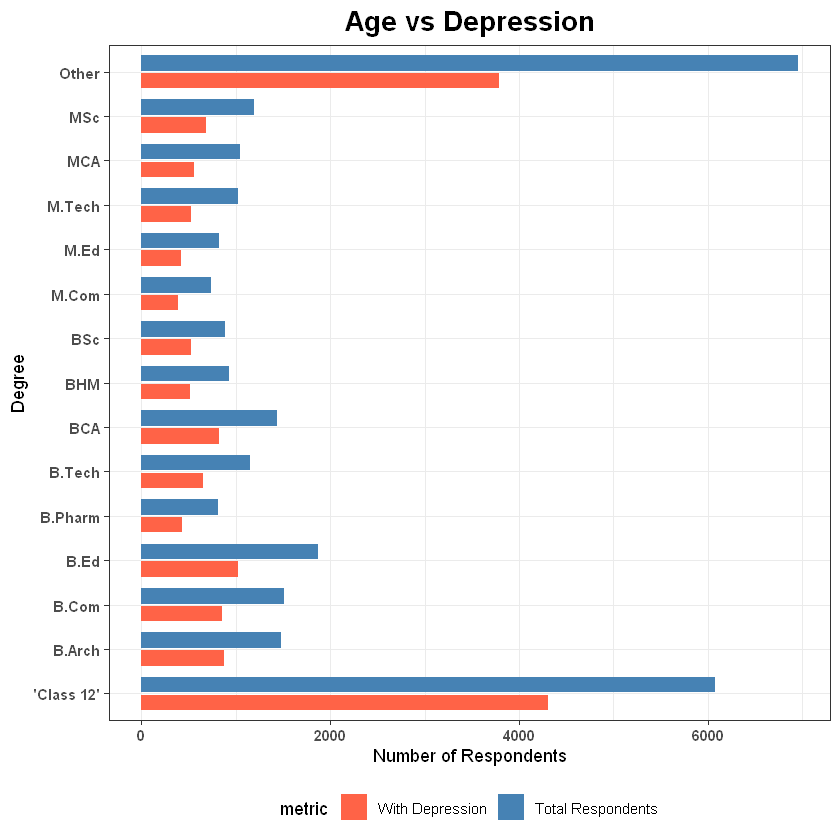

In [29]:
# Calculate the count of unique values in the degree column
degree_count <- data |>
  count(degree, name = "count")

# Display the summary stats of the count of unique values of the degree column
summary(degree_count$count)

# Create a new column 'degree_group' by lumping together degrees with frequency
# below the median. Median of degree frequencies is selected as the threshold
# because it balances the trade-off between reducing clutter in the
# visualization and retaining interpretability
degree_vs_depression <- data |>
  mutate(degree_group = fct_lump_min(
    degree, min = median(degree_count$count), other_level = "Other"
  )) |>
  group_by(degree_group) |>
  summarize(
    total_respondents = n(),
    with_depression = sum(depression),
    depression_percentage = round(with_depression / total_respondents * 100, 2)
  ) |>
  arrange(desc(total_respondents))

# Display the resulting tibble
degree_vs_depression

# Convert the tibble to a longer format
degree_vs_depression_long <- degree_vs_depression |>
  select(degree_group, total_respondents, with_depression) |>
  pivot_longer(
    c(total_respondents, with_depression),
    names_to = "metric",
    values_to = "count"
  ) |>
  mutate(metric = factor(
    metric, levels = c("with_depression", "total_respondents")
  ))

# Visualize the result in a vertical bar plot
ggplot(
  degree_vs_depression_long,
  aes(x = degree_group, y = count, fill = metric)
) +
  geom_col(position = position_dodge(width = 0.8), width = 0.7) +
  coord_flip() +
  labs(title = "Age vs Depression", y = "Number of Respondents", x = "Degree") +
  scale_fill_manual(
    values = c(
      total_respondents = "steelblue",
      with_depression   = "tomato"
    ),
    labels = c(
      total_respondents = "Total Respondents",
      with_depression   = "With Depression"
    )
  ) +
  theme_bw() +
  theme(
    plot.title = element_text(face = "bold", size = 17, hjust = 0.5),
    axis.text.x = element_text(face = "bold"),
    axis.text.y = element_text(face = "bold"),
    legend.position = "bottom"
  )

##### **Interpretation**

* Among Class 12 students, out of 6,080 respondents 4,303 (= 70.77%) reported having depression, showing the highest depression percentage in the dataset.
* Among the students who are pursuing a degree show depression percentages around 50%–59%.
* Degree categories like BCA (1,433 respondents), MSc (1,190 respondents), and B.Tech (1,152 respondents) show slightly lower depression percentages, ranging from 50% to 58%.
* The lowest depression percentages appear among M.Ed (821 respondents) and M.Tech (1,022 respondents) degrees, with values around 50%–51%.

This suggests that while depression is prevalent across all degree programs, **it is notably higher among Class 12 students (the highest at 70.77%)**. Other degree programs show depression levels in the 50-59% range.

### **2. Academic Factor: Do certain academic factors contribute to higher levels of depression among students?**

#### **a. Academic Pressure vs Depression**

academic_pressure,total_respondents,with_depression,depression_percentage
<fct>,<int>,<dbl>,<dbl>
None,9,4,44.44
Very Low,4801,932,19.41
Low,4178,1566,37.48
Moderate,7462,4489,60.16
High,5155,3925,76.14
Very High,6296,5420,86.09


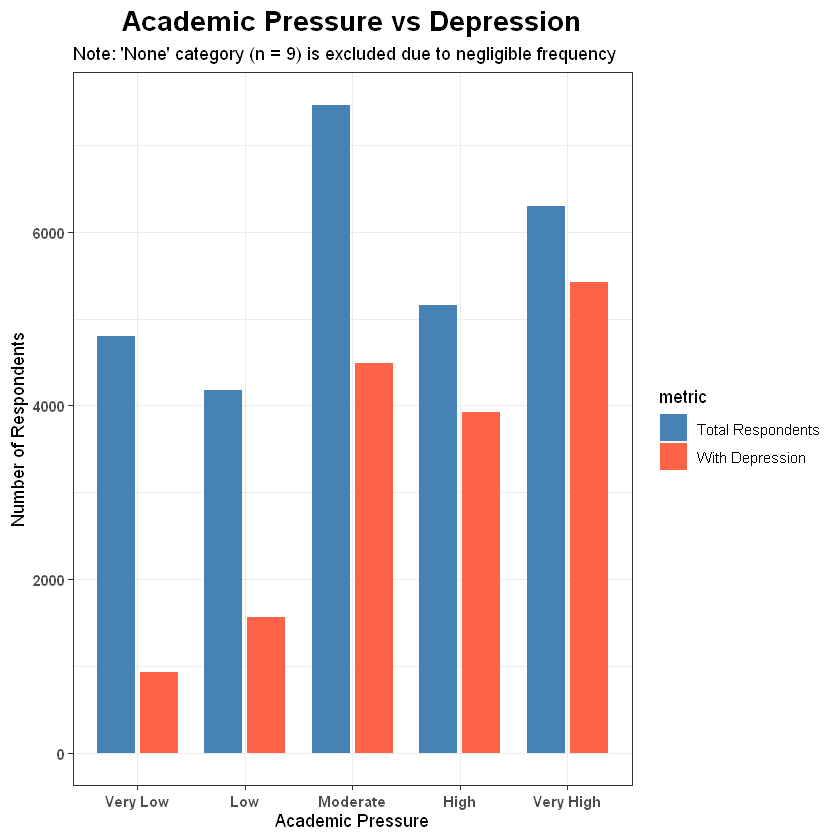

In [30]:
# Group the data by academic pressure and
# compute depression stats across each group
academic_pressure_vs_depression <- data |>
  group_by(academic_pressure) |>
  summarize(
    total_respondents = n(),
    with_depression = sum(depression),
    depression_percentage = round(with_depression / total_respondents * 100, 2)
  )

# Display the resulting tibble
academic_pressure_vs_depression

# Reshape the tibble to long format for bar visualization
academic_pressure_vs_depression_long <- academic_pressure_vs_depression |>
  select(academic_pressure, total_respondents, with_depression) |>
  pivot_longer(
    c(total_respondents, with_depression),
    names_to = "metric",
    values_to = "count"
  ) |>
  mutate(metric = factor(
    metric, levels = c("total_respondents", "with_depression")
  ))

# Visualize the results in a vertical bar plot
ggplot(
  academic_pressure_vs_depression_long |> filter(academic_pressure != "None"),
  aes(x = academic_pressure, y = count, fill = metric)
) +
  geom_col(position = position_dodge(width = 0.8), width = 0.7) +
  scale_fill_manual(
    values = c(
      total_respondents = "steelblue",
      with_depression   = "tomato"
    ),
    labels = c(
      total_respondents = "Total Respondents",
      with_depression   = "With Depression"
    )
  ) +
  labs(
    title = "Academic Pressure vs Depression",
    subtitle = paste0(
      "Note: 'None' category (n = 9) is excluded due to negligible frequency"
    ),
    x = "Academic Pressure",
    y = "Number of Respondents"
  ) +
  theme_bw() +
  theme(
    plot.title = element_text(face = "bold", size = 17, hjust = 0.5),
    axis.text.x = element_text(face = "bold"),
    axis.text.y = element_text(face = "bold")
  )

##### **Interpretation**

* Students reporting "Very Low" academic pressure have the lowest depression rate at 19.41%.
* As academic pressure increases, so does the proportion of students experiencing depression:
    - "Low" pressure: 37.48%
    - "Moderate" pressure: 60.16%
    - "High" pressure: 76.14%
    - "Very High" pressure: a concerning 86.09%

**There is a clear, escalating pattern! Higher academic pressure is strongly associated with higher rate of depression. Students under very high academic pressure are much more likely to experience depression than those under very low pressure.**

####  **b. CGPA vs Depression**

cgpa_group,total_respondents,with_depression,depression_percentage
<fct>,<int>,<dbl>,<dbl>
Very Low (≤ 4.0),9,4,44.44
Average (5.1 – 6.5),7808,4446,56.94
Good (6.6 – 8.0),7516,4260,56.68
Very Good (8.1 – 9.0),6336,4039,63.75
Excellent (9.1 - 10),6232,3587,57.56


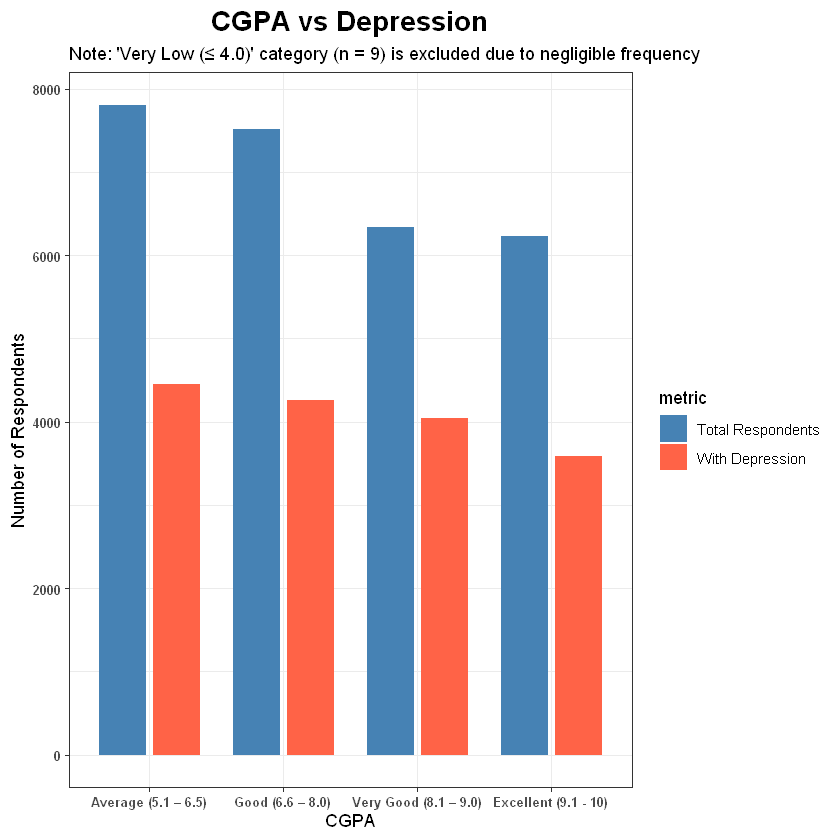

In [31]:
# Create a cgpa_group column based on defined academic performance ranges
# and compute depression stats across each group
cgpa_vs_depression <- data |>
  mutate(
    cgpa_group = case_when(
      cgpa <= 4 ~ "Very Low (≤ 4.0)",
      cgpa > 4 & cgpa <= 5 ~ "Low (4.1 – 5.0)",
      cgpa > 5 & cgpa <= 6.5 ~ "Average (5.1 – 6.5)",
      cgpa > 6.5 & cgpa <= 8 ~ "Good (6.6 – 8.0)",
      cgpa > 8 & cgpa <= 9 ~ "Very Good (8.1 – 9.0)",
      cgpa > 9 & cgpa <= 10 ~ "Excellent (9.1 - 10)",
      TRUE ~ "Unknown"
    ),
    cgpa_group = factor(
      cgpa_group,
      levels = c(
        "Very Low (≤ 4.0)", "Low (4.1 – 5.0)", "Average (5.1 – 6.5)",
        "Good (6.6 – 8.0)", "Very Good (8.1 – 9.0)", "Excellent (9.1 - 10)",
        "Unknown"
      )
    )
  ) |>
  group_by(cgpa_group) |>
  summarize(
    total_respondents = n(),
    with_depression = sum(depression),
    depression_percentage = round(with_depression / total_respondents * 100, 2)
  )

# Display the resulting tibble
cgpa_vs_depression

# Reshape the tibble to long format for bar visualization
cgpa_vs_depression_long <- cgpa_vs_depression |>
  select(cgpa_group, total_respondents, with_depression) |>
  pivot_longer(
    c(total_respondents, with_depression),
    names_to = "metric",
    values_to = "count"
  ) |>
  mutate(metric = factor(
    metric, levels = c("total_respondents", "with_depression")
  ))

# Visualize the results in a vertical bar plot
ggplot(cgpa_vs_depression_long |> filter(cgpa_group != "Very Low (≤ 4.0)"),
  aes(x = cgpa_group, y = count, fill = metric)
) +
  geom_col(position = position_dodge(width = 0.8), width = 0.7) +
  scale_fill_manual(
    values = c(
      total_respondents = "steelblue",
      with_depression   = "tomato"
    ),
    labels = c(
      total_respondents = "Total Respondents",
      with_depression   = "With Depression"
    )
  ) +
  labs(
    title = "CGPA vs Depression",
    subtitle = paste(
      "Note: 'Very Low (≤ 4.0)' category (n = 9) is excluded",
      "due to negligible frequency"
    ),
    x = "CGPA",
    y = "Number of Respondents"
  ) +
  theme_bw() +
  theme(
    plot.title = element_text(face = "bold", size = 17, hjust = 0.5),
    axis.text.x = element_text(face = "bold", size = 7.5),
    axis.text.y = element_text(face = "bold", size = 7.5)
  )


##### **Interpretation**

* Students across all CGPA groups show high levels of depression, with percentages ranging from 56.68% to 63.75%.
* Interestingly, the "Very Good (8.1 – 9.0)" CGPA group exhibits the highest proportion of students with depression (63.75%), suggesting that even academically strong students are not immune to mental health struggles.
* The depression rate remains consistently high even in the "Excellent (9.1 – 10)" group at 57.56%, slightly higher than that of the "Good" and "Average" groups.

Higher academic performance does not necessarily correlate with lower depression levels. In fact, students with higher CGPAs may experience increased psychological pressure or perfectionism, which could contribute to elevated levels of depression.


#### **c. Study Satisfaction vs Depression**

study_satisfaction,total_respondents,with_depression,depression_percentage
<fct>,<int>,<dbl>,<dbl>
None,10,6,60.00
Very Low,5451,3857,70.76
Low,5838,3768,64.54
Moderate,5821,3353,57.60
High,6359,3264,51.33
Very High,4422,2088,47.22


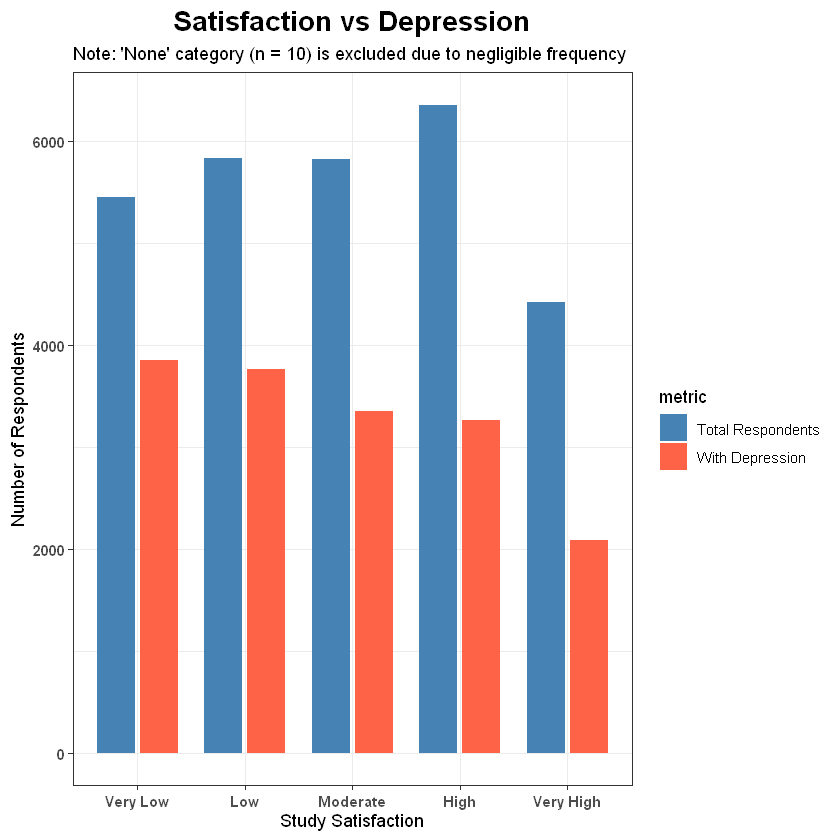

In [32]:
# Group the data by study satisfaction and
# compute depression stats across each group
study_satisfaction_vs_depression <- data |>
  group_by(study_satisfaction) |>
  summarize(
    total_respondents = n(),
    with_depression = sum(depression),
    depression_percentage = round(with_depression / total_respondents * 100, 2)
  )

# Display the resulting tibble
study_satisfaction_vs_depression

# Reshape the tibble to long format for bar visualization
study_satisfaction_vs_depression_long <- study_satisfaction_vs_depression |>
  select(study_satisfaction, total_respondents, with_depression) |>
  pivot_longer(
    c(total_respondents, with_depression),
    names_to = "metric",
    values_to = "count"
  ) |>
  mutate(metric = factor(
    metric, levels = c("total_respondents", "with_depression")
  ))

# Visualize the results in a vertical bar plot
ggplot(
  study_satisfaction_vs_depression_long |> filter(study_satisfaction != "None"),
  aes(x = study_satisfaction, y = count, fill = metric)
) +
  geom_col(position = position_dodge(width = 0.8), width = 0.7) +
  scale_fill_manual(
    values = c(
      total_respondents = "steelblue",
      with_depression   = "tomato"
    ),
    labels = c(
      total_respondents = "Total Respondents",
      with_depression   = "With Depression"
    )
  ) +
  labs(
    title = "Satisfaction vs Depression",
    subtitle = paste0(
      "Note: 'None' category (n = 10) is excluded due to negligible frequency"
    ),
    x = "Study Satisfaction",
    y = "Number of Respondents"
  ) +
  theme_bw() +
  theme(
    plot.title = element_text(face = "bold", size = 17, hjust = 0.5),
    axis.text.x = element_text(face = "bold"),
    axis.text.y = element_text(face = "bold")
  )

##### **Interpretation**

There appears to be a strong inverse relationship between students’ study satisfaction and their likelihood of experiencing depression. As study satisfaction increases, the percentage of students with depression consistently decreases.
- Among students with Very Low satisfaction, 70.76% reported depression — the highest across all groups.
- This percentage gradually declines to 64.54% for those with Low satisfaction, 57.60% for Moderate, and 51.33% for High.
- The lowest rate of depression (47.22%) is observed among students who reported Very High satisfaction.

**This trend suggests that higher academic satisfaction is associated with lower depression rates.**

#### **d. Study Hours vs Depression**

Minimum Value in the work_study_hours column: 0 
Maximum Value in the work_study_hours column: 12

study_hours_group,total_respondents,with_depression,depression_percentage
<fct>,<int>,<dbl>,<dbl>
0–2 hrs (Low),4440,1764,39.73
3–5 hrs (Moderate),4380,2218,50.64
6–8 hrs (High),6757,4032,59.67
9–12 hrs (Very High),12324,8322,67.53


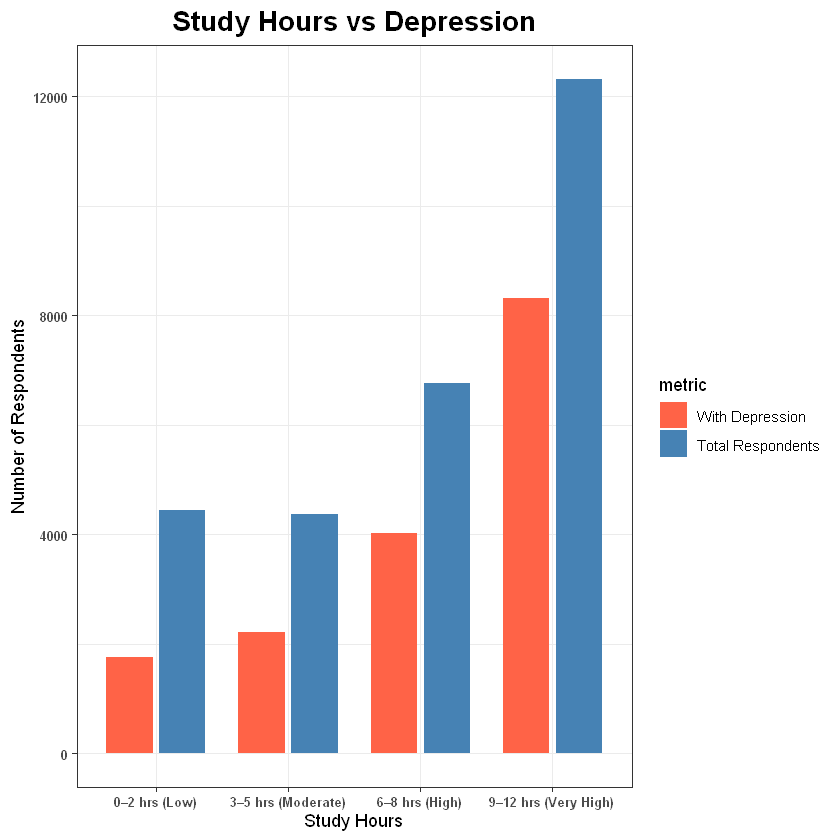

In [33]:
# Display the minimum and the maximum value in the work_study_hours column
cat(
  "Minimum Value in the work_study_hours column:",
  min(data$work_study_hours),
  "\n"
)
cat(
  "Maximum Value in the work_study_hours column:",
  max(data$work_study_hours)
)

# Create a study_hours_group column based on defined study hours ranges
# and compute depression stats across each group
study_hours_vs_depression <- data |>
  mutate(
    study_hours_group = case_when(
      work_study_hours <= 2 ~ "0–2 hrs (Low)",
      work_study_hours > 2 & work_study_hours <= 5 ~ "3–5 hrs (Moderate)",
      work_study_hours > 5 & work_study_hours <= 8  ~ "6–8 hrs (High)",
      work_study_hours > 8 & work_study_hours <= 12 ~ "9–12 hrs (Very High)"
    ),
    study_hours_group = factor(
      study_hours_group,
      levels = c(
        "0–2 hrs (Low)", "3–5 hrs (Moderate)",
        "6–8 hrs (High)", "9–12 hrs (Very High)"
      )
    )
  ) |>
  group_by(study_hours_group) |>
  summarize(
    total_respondents = n(),
    with_depression = sum(depression),
    depression_percentage = round(with_depression / total_respondents * 100, 2)
  )

# Display the resulting tibble
study_hours_vs_depression

# Reshape the tibble to long format for bar visualization
study_hours_vs_depression_long <- study_hours_vs_depression |>
  select(study_hours_group, total_respondents, with_depression) |>
  pivot_longer(
    c(total_respondents, with_depression),
    names_to = "metric",
    values_to = "count"
  ) |>
  mutate(metric = factor(
    metric, levels = c("with_depression", "total_respondents")
  ))

# Visualize the results in a vertical bar plot
ggplot(
  study_hours_vs_depression_long,
  aes(x = study_hours_group, y = count, fill = metric)
) +
  geom_col(position = position_dodge(width = 0.8), width = 0.7) +
  scale_fill_manual(
    values = c(
      total_respondents = "steelblue",
      with_depression   = "tomato"
    ),
    labels = c(
      total_respondents = "Total Respondents",
      with_depression   = "With Depression"
    )
  ) +
  labs(
    title = "Study Hours vs Depression",
    x = "Study Hours",
    y = "Number of Respondents"
  ) +
  theme_bw() +
  theme(
    plot.title = element_text(face = "bold", size = 17, hjust = 0.5),
    axis.text.x = element_text(face = "bold", size = 7.5),
    axis.text.y = element_text(face = "bold", size = 7.5)
  )


##### **Interpretation**

* Low study hours (0–2 hrs): Of the 4,440 students in this group, 39.73% are reported to have depression.
* Moderate study hours (3–5 hrs): Among 4,380 students, 50.64% report experiencing depression.
* High study hours (6–8 hrs): In this group of 6,757 students, 59.67% experience depression.
* Very high study hours (9–12 hrs): This category shows the highest depression percentage, with 67.53% of 12,324 students reporting depression.

**The analysis reveals a clear upward trend between academic workload and depression. Students who dedicate more hours to studying or working tend to exhibit higher levels of depression. These findings indicate that prolonged academic engagement may be a potential stressor contributing to students’ mental health challenges.**

### **3. Lifestyle & Mental Health Background: Do certain lifestyle habits or mental health background factors increase the likelihood of depression among students?**

#### **a. Sleep Duration vs Depression**

sleep_duration,total_respondents,with_depression,depression_percentage
<fct>,<int>,<dbl>,<dbl>
Less than 5 hours,8310,5361,64.51
5-6 hours,6183,3517,56.88
7-8 hours,7346,4371,59.50
More than 8 hours,6044,3078,50.93
Others,18,9,50.00


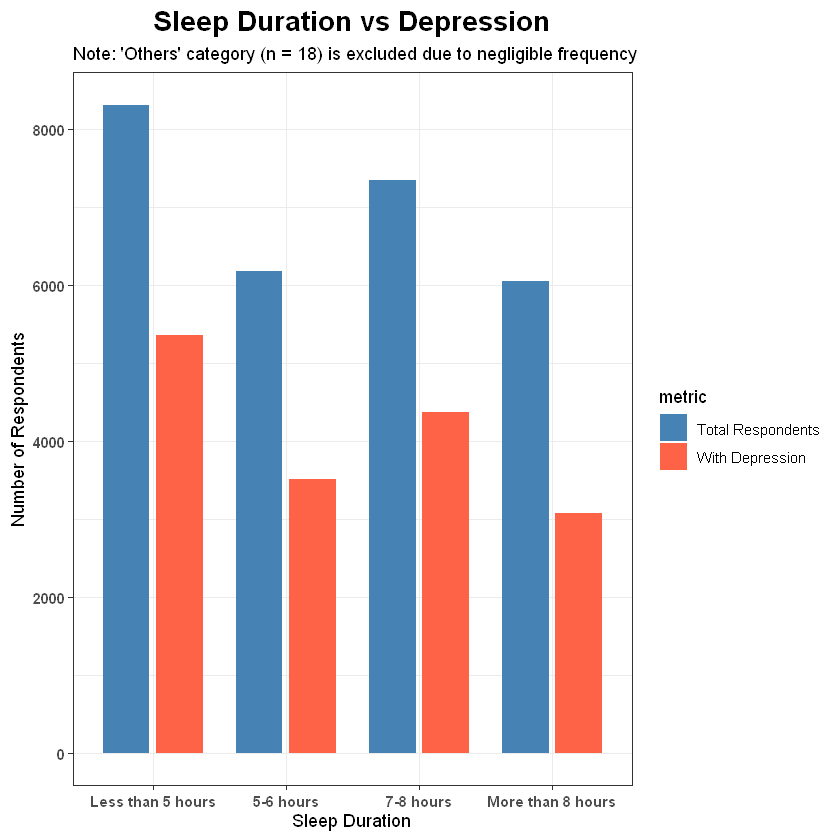

In [34]:
# Group the data by sleep duration and
# compute depression stats across each group
sleep_duration_vs_depression <- data |>
  group_by(sleep_duration) |>
  summarize(
    total_respondents = n(),
    with_depression = sum(depression),
    depression_percentage = round(with_depression / total_respondents * 100, 2)
  )

# Display the resulting tibble
sleep_duration_vs_depression

# Reshape the tibble to long format for bar visualization
sleep_duration_vs_depression_long <- sleep_duration_vs_depression |>
  select(sleep_duration, total_respondents, with_depression) |>
  pivot_longer(
    c(total_respondents, with_depression),
    names_to = "metric",
    values_to = "count"
  ) |>
  mutate(metric = factor(
    metric, levels = c("total_respondents", "with_depression")
  ))

# Visualize the results in a vertical bar plot
ggplot(
  sleep_duration_vs_depression_long |> filter(sleep_duration != "Others"),
  aes(x = sleep_duration, y = count, fill = metric)
) +
  geom_col(position = position_dodge(width = 0.8), width = 0.7) +
  scale_fill_manual(
    values = c(
      total_respondents = "steelblue",
      with_depression   = "tomato"
    ),
    labels = c(
      total_respondents = "Total Respondents",
      with_depression   = "With Depression"
    )
  ) +
  labs(
    title = "Sleep Duration vs Depression",
    subtitle = paste0(
      "Note: 'Others' category (n = 18) is excluded due to negligible frequency"
    ),
    x = "Sleep Duration",
    y = "Number of Respondents"
  ) +
  theme_bw() +
  theme(
    plot.title = element_text(face = "bold", size = 17, hjust = 0.5),
    axis.text.x = element_text(face = "bold"),
    axis.text.y = element_text(face = "bold")
  )

##### **Interpretation**

* Highest depression rate is among students sleeping less than 5 hours (64.5%).
* As sleep duration increases, the depression rate generally declines, with the lowest rate (50.9%) in the “More than 8 hours” group.
* Interestingly, students getting 5–6 hours of sleep have a slightly lower depression rate (56.9%) than those sleeping 7–8 hours (59.5%)

Students who sleep less than 5 hours are the most vulnerable to depression. However, across other sleep durations, the relationship is not strictly linear as students sleeping 7–8 hours experience a higher rate of depression compared to those sleeping 5–6 hours, suggesting that factors beyond just sleep quantity, such as sleep quality or lifestyle stressors, may influence depression levels.

#### **b. Dietary Habits vs Depression**

dietary_habits,total_respondents,with_depression,depression_percentage
<fct>,<int>,<dbl>,<dbl>
Unhealthy,10317,7297,70.73
Moderate,9921,5558,56.02
Healthy,7651,3473,45.39
Others,12,8,66.67


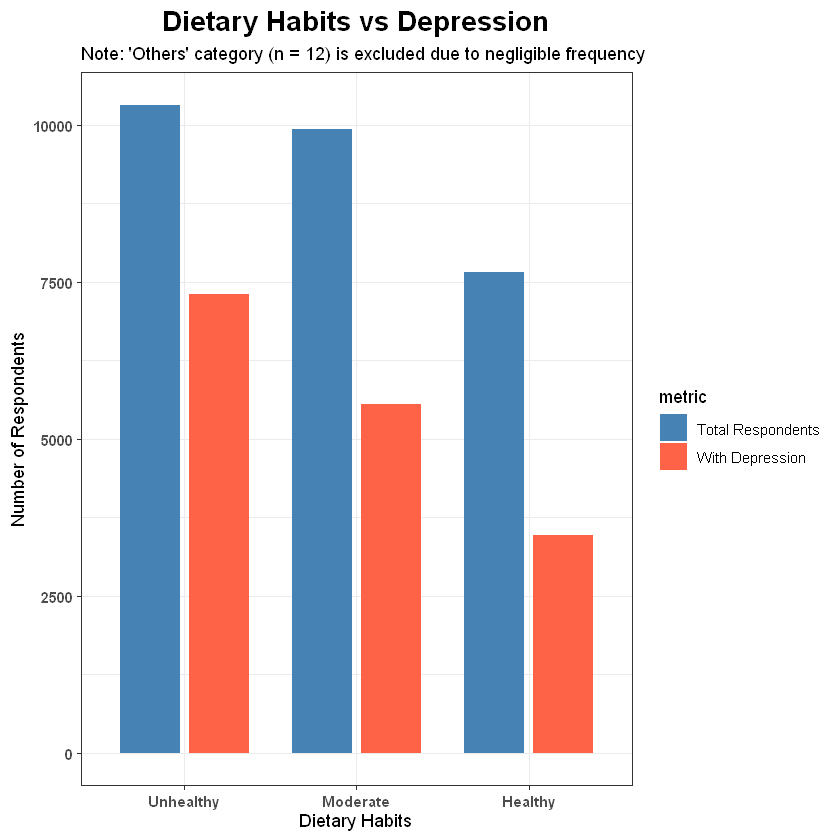

In [35]:
# Group the data by dietary habits and
# compute depression stats across each group
dietary_habits_vs_depression <- data |>
  group_by(dietary_habits) |>
  summarize(
    total_respondents = n(),
    with_depression = sum(depression),
    depression_percentage = round(with_depression / total_respondents * 100, 2)
  )

# Display the resulting tibble
dietary_habits_vs_depression

# Reshape the tibble to long format for bar visualization
dietary_habits_vs_depression_long <- dietary_habits_vs_depression |>
  select(dietary_habits, total_respondents, with_depression) |>
  pivot_longer(
    c(total_respondents, with_depression),
    names_to = "metric",
    values_to = "count"
  ) |>
  mutate(metric = factor(
    metric, levels = c("total_respondents", "with_depression")
  ))

# Visualize the results in a vertical bar plot
ggplot(
  dietary_habits_vs_depression_long |> filter(dietary_habits != "Others"),
  aes(x = dietary_habits, y = count, fill = metric)
) +
  geom_col(position = position_dodge(width = 0.8), width = 0.7) +
  scale_fill_manual(
    values = c(
      total_respondents = "steelblue",
      with_depression   = "tomato"
    ),
    labels = c(
      total_respondents = "Total Respondents",
      with_depression   = "With Depression"
    )
  ) +
  labs(
    title = "Dietary Habits vs Depression",
    subtitle = paste0(
      "Note: 'Others' category (n = 12) is excluded due to negligible frequency"
    ),
    x = "Dietary Habits",
    y = "Number of Respondents"
  ) +
  theme_bw() +
  theme(
    plot.title = element_text(face = "bold", size = 17, hjust = 0.5),
    axis.text.x = element_text(face = "bold"),
    axis.text.y = element_text(face = "bold")
  )

##### **Interpretation**

* Students reporting Unhealthy dietary habits have the highest depression prevalence (70.7%).
* Those with Moderate habits show a lower rate (56.0%).
* Students with Healthy habits have the lowest depression rate (45.4%).

**There is a strong inverse association between dietary quality and depression! Students with unhealthy eating patterns exhibit the highest rates of depression, while those with healthy diets show substantially lower prevalence.**

#### **c. Financial Stress vs Depression**

financial_stress,total_respondents,with_depression,depression_percentage
<fct>,<int>,<dbl>,<dbl>
Very Low,5121,1632,31.87
Low,5061,2175,42.98
Moderate,5226,3080,58.94
High,5775,3990,69.09
Very High,6718,5459,81.26


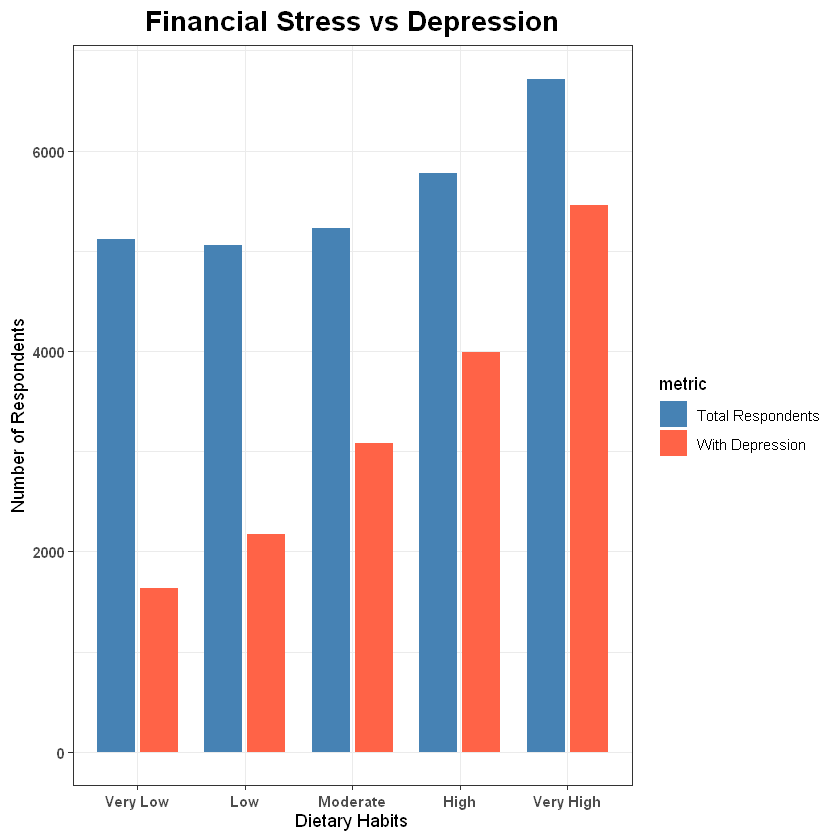

In [36]:
# Group the data by financial stress and
# compute depression stats across each group
financial_stress_vs_depression <- data |>
  group_by(financial_stress) |>
  summarize(
    total_respondents = n(),
    with_depression = sum(depression),
    depression_percentage = round(with_depression / total_respondents * 100, 2)
  )

# Display the resulting tibble
financial_stress_vs_depression

# Reshape the tibble to long format for bar visualization
financial_stress_vs_depression_long <- financial_stress_vs_depression |>
  select(financial_stress, total_respondents, with_depression) |>
  pivot_longer(
    c(total_respondents, with_depression),
    names_to = "metric",
    values_to = "count"
  ) |>
  mutate(metric = factor(
    metric, levels = c("total_respondents", "with_depression")
  ))

# Visualize the results in a vertical bar plot
ggplot(
  financial_stress_vs_depression_long,
  aes(x = financial_stress, y = count, fill = metric)
) +
  geom_col(position = position_dodge(width = 0.8), width = 0.7) +
  scale_fill_manual(
    values = c(
      total_respondents = "steelblue",
      with_depression   = "tomato"
    ),
    labels = c(
      total_respondents = "Total Respondents",
      with_depression   = "With Depression"
    )
  ) +
  labs(
    title = "Financial Stress vs Depression",
    x = "Dietary Habits",
    y = "Number of Respondents"
  ) +
  theme_bw() +
  theme(
    plot.title = element_text(face = "bold", size = 17, hjust = 0.5),
    axis.text.x = element_text(face = "bold"),
    axis.text.y = element_text(face = "bold")
  )

##### **Interpretation**

There is a clear, direct relationship between financial stress and depression prevalence among students:
* Very Low financial stress: 31.9% of students are depressed.
* Low stress: 43.0% depressed.
* Moderate stress: 58.9% depressed.
* High stress: 69.1% depressed.
* Very High stress: 81.3% depressed.

**This strong upward trend clearly indicates that higher financial stress is strongly associated with a greater risk of depression.**

#### **d. Family History of Mental Illness vs depression**

family_history_of_mental_illness,total_respondents,with_depression,depression_percentage
<fct>,<int>,<dbl>,<dbl>
Yes,13503,8273,61.27
No,14398,8063,56.00


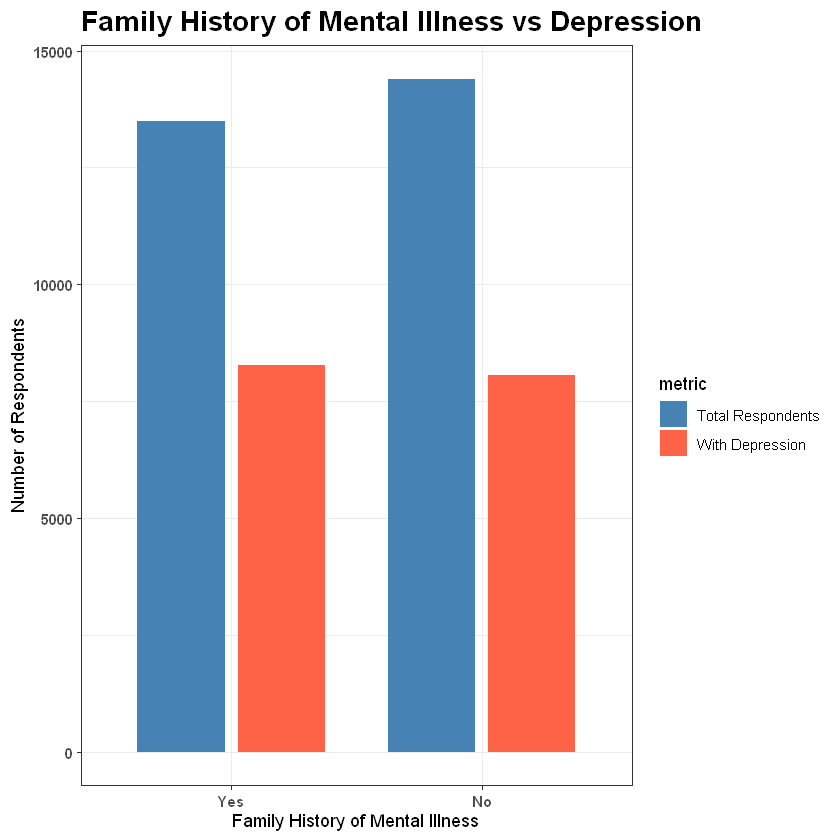

In [41]:
# Group the data by family history of mental illness and
# compute depression stats across each group
family_history_vs_depression <- data |>
  group_by(family_history_of_mental_illness) |>
  summarize(
    total_respondents = n(),
    with_depression = sum(depression),
    depression_percentage = round(with_depression / total_respondents * 100, 2)
  )

# Display the resulting tibble
family_history_vs_depression

# Reshape the tibble to long format for bar visualization
family_history_vs_depression_long <- family_history_vs_depression |>
  select(
    family_history_of_mental_illness,
    total_respondents,
    with_depression
  ) |>
  pivot_longer(
    c(total_respondents, with_depression),
    names_to = "metric",
    values_to = "count"
  ) |>
  mutate(metric = factor(
    metric, levels = c("total_respondents", "with_depression")
  ))

# Visualize the results in a vertical bar plot
ggplot(
  family_history_vs_depression_long,
  aes(x = family_history_of_mental_illness, y = count, fill = metric)
) +
  geom_col(position = position_dodge(width = 0.8), width = 0.7) +
  scale_fill_manual(
    values = c(
      total_respondents = "steelblue",
      with_depression   = "tomato"
    ),
    labels = c(
      total_respondents = "Total Respondents",
      with_depression   = "With Depression"
    )
  ) +
  labs(
    title = "Family History of Mental Illness vs Depression",
    x = "Family History of Mental Illness",
    y = "Number of Respondents"
  ) +
  theme_bw() +
  theme(
    plot.title = element_text(face = "bold", size = 17),
    axis.text.x = element_text(face = "bold"),
    axis.text.y = element_text(face = "bold")
  )

##### **Interpretation**

* Among the 13,503 respondents who reported a family history of mental illness, 8,273 (61.27%) experienced depression.
* In contrast, among the 14,398 respondents without such a family history, 8,063 (56.00%) reported depression.

While students with a family history of mental illness show a higher depression rate (61.3%) compared to those without such a history (56.0%), the difference is relatively modest at around 5%.
This suggests that although a family history of mental illness may slightly increase the risk, depression is still highly prevalent among students even without such a background.

#### **e. Chi-Square Test of Independence: Suicidal Thoughts vs Depression**

**Hypotheses:**
* **Null Hypothesis ($𝐻_0$):** There is no association between suicidal and depression (i.e., the two variables are independent).

* **Alternative Hypothesis ($𝐻_1$):** There is an association between having suicidal thoughts and depression (i.e., the two variables are not independent).

In [37]:
# Create a contingency table between suicidal thoughts and depression
contingency_table <- table(
  data$have_you_ever_had_suicidal_thoughts,
  data$depression
)

# Specify the significance level: 0.05
# A significance level of 0.05 is commonly used in research,
# meaning we are willing to accept a 5% risk of incorrectly rejecting
# the null hypothesis (Type I error).
alpha <- 0.05

# Conduct the chi-square test of independence
chi_sq <- chisq.test(contingency_table)

# Print the results
cat(
  paste("Chi-square Statistic (χ²):", round(chi_sq$statistic, 2)),
  paste("Degrees of Freedom (df):", chi_sq$parameter),
  paste("Significance level (α):", alpha),
  paste("P-value:", chi_sq$p.value),
  sep = "\n"
)

Chi-square Statistic (χ²): 8323.87
Degrees of Freedom (df): 1
Significance level (α): 0.05
P-value: 0


##### **Interpretation**

The chi-square test of independence between suicidal thoughts and depression yielded a chi-square statistic of 8323.87 with 1 degree of freedom. The p-value is less than 0.001, which is significantly lower than the chosen significance level of 0.05.
**Thus, we reject the null hypothesis ($H_0$) and conclude that there is a statistically significant association between experiencing suicidal thoughts and having depression among the student**

#### **Excluded columns in the analysis** 

The columns Job Satisfaction and Work Pressure were not selected for analysis because the majority of the respondents in the dataset were students rather than working professionals. As a result, these variables had very low response rates and were not relevant for the primary focus of this study, which was to explore factors associated with student depression.

## **The Act Phase**

### **Key Findings**

* **Age and Academic Stage Correlate Strongly with Depression:**
    
    Younger students, especially those aged 18–21 and Class 12 students, report the highest rates of depression. This suggests that earlier academic stages and younger age groups are more vulnerable to mental health struggles.

* **Academic Pressure is a Major Driver of Depression:** 

    Students under very high academic pressure show a significantly higher depression rate (86%), suggesting that academic stress is strongly related to student mental health challenges.

* **Study Satisfaction and Depression:**

    An inverse relationship was observed between study Satisfaction and depression. Higher study satisfaction correlates with lower depression rates. Only 47.22% of students with "Very High" satisfaction reported depression compared to 70.76% with "Very Low" satisfaction.

* **Study Hours and Depression:**
    
    More study hours are associated with higher depression rates. Students studying 9–12 hours daily show a depression rate of 67.53%, indicating that prolonged academic engagement may contribute to mental health issues.

* **High Academic Achievement Does Not Protect Against Depression:**
    
    Depression remains high even among students with strong academic performance (higher CGPAs), suggesting that academic success does not necessarily equate to better mental well-being.

* **Lifestyle Factors Such as Sleep and Diet Show Important Associations:**
    
    Students sleeping less than 5 hours and those with unhealthy dietary habits show notably higher depression rates, indicating that lifestyle factors are strongly associated with mental health outcomes.

* **Financial Stress and Depression are Closely Linked:**
    
    Higher financial stress levels are strongly associated with higher depression rates, rising dramatically from 31.9% (Very Low stress) to 81.3% (Very High stress), indicating that economic insecurity significantly impacts student mental health.

* **Suicidal Thoughts and Depression are Statistically Connected:**

    A highly significant chi-square test result confirms that students experiencing suicidal thoughts are far more likely to report having depression, emphasizing the seriousness of early mental health intervention.    

### **Limitations**

* **Self-reported data bias:** 

    Since the data is based on self-reported surveys, there is a possibility of inaccuracies due to misunderstanding, exaggeration, or social desirability bias.

* **Cross-sectional nature:** 
    As the dataset captures responses at a single point in time, it limits the ability to determine cause-and-effect relationships between depression and other factors.

* **Missing and subjective variables:** 

    Important factors like access to counseling, social support systems, substance use, and other stressors were not included or measured, which may limit the comprehensiveness of the analysis.

### **My Recommendations**

* **Address High Academic Pressure:**

    Academic pressure has been strongly linked to higher rates of depression, especially for students under very high academic stress. Institutions should consider implementing measures to reduce academic pressure, such as offering flexible deadlines, encouraging work-life balance, and promoting student well-being initiatives. Educators should also be trained to recognize the signs of mental distress among students.

* **Promote Healthy Lifestyle Habits:** 

    The inverse relationship between both healthy dietary habits and sleep duration with depression suggests that promoting healthier lifestyles can be a preventive measure. Students should be encouraged to implement healthier lifestyle choices, including better nutrition and adequate sleep. 

* **Financial Wellness Initiatives:**

    Given the strong association between financial stress and depression, educational institutions can offer financial literacy programs, scholarships, and counseling services to help students manage financial pressures more effectively.

* **Enhance Mental Health Support Services:**

    * Expand on-campus counseling availability and promote awareness so students know how to access help early.
    * Introduce regular mental-health check-ins or screening events




### **Conclusion**

In conclusion, this analysis reveals that student depression is multifaceted and strongly associated with academic stress, financial worry, and lifestyle factors affecting nearly all groups regardless of gender, CGPA, or family history. High academic pressure and long study hours are strongly associated with higher depression rates, while greater study satisfaction, healthier dietary habits, and sufficient sleep are linked to lower depression rates. Additionally, suicidal thoughts show a significant positive association with depression. 

By reducing excessive academic pressure, promoting healthy lifestyle habits, and providing financial initiatives and enhancing mental health support system, institutions can create a more protective environment for mental health. However, the absence of certain key variables, such as access to counseling services and family support, limits the scope of the analysis, and future research should aim to include these factors for a more comprehensive understanding of student mental health. 

While causality cannot be definitively established from this cross‐sectional data, the consistent associations underscore clear areas for action. Implementing these recommendations and expanding data collection efforts, institutions can help ensure that students have the necessary support and resources to succeed academically and maintain their emotional well-being.